# 05 — Chapter 1: Data Setup & Feature Engineering

This notebook prepares the modelling dataset for Chapter 1 by validating the Chapter 0 output, running basic sanity checks, and assembling the final feature set for the salary model.

### Purpose
- Confirm that the Chapter 0 pipeline produced clean, consistent data.
- Perform a light exploratory pass to understand available variables.
- Construct the final set of features used in the salary prediction model.

### What this notebook does
- Loads the Chapter 0 dataset and checks structure, missingness, and salary fields.
- Runs the benchmark sanity checks to ensure no structural issues remain.
- Selects and organises the categorical and skill features used for modelling.
- Applies integer encoding to categorical fields.
- Assembles the final modelling-ready DataFrame combining encoded categorical features and all 27 skill indicators.

### Outcome
A validated and fully engineered dataset saved as  
`data/processed/salary_model_dfv01.csv`,  
which serves as the input for all Chapter 1 salary and skill-demand models.

## Directory set-up

In [1]:
import sys
from pathlib import Path

# >>>> CHANGE THIS if your path is a bit different <<<<
SRC_ROOT = Path("/Users/alejandrofp/Desktop/Projects/03_Flagship_Portfolio/job-intelligence-engine/src")

print("SRC_ROOT exists? ", SRC_ROOT.exists())
print("SRC_ROOT path    ", SRC_ROOT)

if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

print("Added to sys.path")

SRC_ROOT exists?  True
SRC_ROOT path     /Users/alejandrofp/Desktop/Projects/03_Flagship_Portfolio/job-intelligence-engine/src
Added to sys.path


In [2]:
import pkgutil

print("job_intel visible in SRC_ROOT?:",
      any(m.name == "job_intel" for m in pkgutil.iter_modules([str(SRC_ROOT)])))

job_intel visible in SRC_ROOT?: True


## Libraries

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

## Generate data from the pipeline

In [4]:
from job_intel.pipelines.chapter0_build_base_dataset import build_chapter0_base_dataset

df_ch0 = build_chapter0_base_dataset()

Loading raw jobs ...
Raw combined shape: (6162, 16)
Replaced -1 with NAs
Added location features.
Simplified ownership.
Converted year to integer.
Dropped uneccesary features (Nas and extremely complex) - Easy Apply, Competitors, Company Name and Revenue.
Added job_description_clean.
Added title/seniority/family features (using cleaned description).
Added domain from lookup (missing=0).
Added salary features from 'Salary Estimate'.
Added skill flag features.
Dropping columns: ['Job Title', 'job_title_for_skills', 'job_title_raw', 'Salary Estimate', 'seniority_roman', 'seniority_title', 'seniority_description', 'state_hq']
Saved Chapter 0 processed dataset to: /Users/alejandrofp/Desktop/Projects/03_Flagship_Portfolio/job-intelligence-engine/data/processed/jobs_ch0.csv (shape=(6162, 47))


In [5]:
df_ch0

,Job Description,Rating,Size,Founded,Industry,Sector,role_source,state,ownership_clean,job_description_clean,...,cloud__advanced,db_storage__basic,db_storage__intermediate,db_storage__advanced,productivity_workflow__basic,productivity_workflow__intermediate,productivity_workflow__advanced,soft_skills__core,soft_skills__leadership,domain_specific__none
0,"ABOUT HOPPER\n\nAt Hopper, we’re on a mission ...",3.5,501 to 1000 employees,2007,Travel Agencies,Travel & Tourism,data_scientist,NY,private,hopper mission make booking travel faster easi...,...,0,1,0,0,0,0,0,1,0,0
1,"At Noom, we use scientifically proven methods ...",4.5,1001 to 5000 employees,2008,"Health, Beauty, & Fitness",Consumer Services,data_scientist,NY,private,noom use scientifically proven methods help us...,...,0,1,0,0,0,0,0,1,0,0
2,Decode_M\n\nhttps://www.decode-m.com/\n\nData ...,NaN,1 to 50 employees,<NA>,Unknown,Unknown,data_scientist,NY,unknown,decode https www com data science manager job ...,...,0,0,0,0,0,0,0,1,1,1
3,Sapphire Digital seeks a dynamic and driven mi...,3.4,201 to 500 employees,2019,Internet,Information Technology,data_scientist,NJ,private,sapphire digital seeks dynamic driven mid leve...,...,0,1,0,0,0,0,0,1,1,0
4,"Director, Data Science - (200537)\nDescription...",3.4,51 to 200 employees,2007,Advertising & Marketing,Business Services,data_scientist,NY,private,director data science description edelman inte...,...,0,0,0,0,0,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6157,Maintains systems to protect data from unautho...,2.5,51 to 200 employees,<NA>,Staffing & Outsourcing,Business Services,data_analyst,CO,private,maintains systems protect data unauthorized us...,...,0,0,0,0,0,0,0,0,0,0
6158,Position:\nSenior Data Analyst (Corporate Audi...,2.9,10000+ employees,1935,Wholesale,Business Services,data_analyst,CO,public,position senior data analyst corporate audit j...,...,0,1,1,0,0,0,0,1,1,0
6159,"Title: Technical Business Analyst (SQL, Data a...",NaN,Unknown,<NA>,Unknown,Unknown,data_analyst,CO,unknown,title technical business analyst sql data anal...,...,0,1,0,0,1,0,0,1,1,1
6160,Summary\n\nResponsible for working cross-funct...,3.1,201 to 500 employees,1984,Enterprise Software & Network Solutions,Information Technology,data_analyst,CO,private,summary responsible working cross functionally...,...,0,1,1,0,0,0,0,1,1,0


In [6]:
df_ch0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6162 entries, 0 to 6161
Data columns (total 47 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Job Description                           6162 non-null   object 
 1   Rating                                    5481 non-null   float64
 2   Size                                      6162 non-null   object 
 3   Founded                                   4525 non-null   Int64  
 4   Industry                                  6162 non-null   object 
 5   Sector                                    6162 non-null   object 
 6   role_source                               6162 non-null   object 
 7   state                                     6162 non-null   object 
 8   ownership_clean                           6162 non-null   object 
 9   job_description_clean                     6162 non-null   object 
 10  job_title_base                      

In [7]:
df_ch0.describe(include = 'O')

,Job Description,Size,Industry,Sector,role_source,state,ownership_clean,job_description_clean,job_title_base,seniority_combined,job_title_norm,job_title_family,domain,title_plus_description
count,6162,6162,6162,6162,6162,6162,6162,6162,6162,6162,6162,6162,6162,6162
unique,5309,8,105,26,2,20,5,5219,2061,10,75,4,7,5259
top,The U.S. Department of the Treasury has a dist...,10000+ employees,Unknown,Information Technology,data_scientist,CA,private,job description interpret data analyze results...,data analyst,unknown,data analyst,data_analyst,general_data,statistician data scientist 12 month roster...
freq,14,1368,899,1694,3909,1695,3233,27,1197,3380,2668,3035,3639,14


## Benchmark check

In [8]:
from job_intel.config import INTERIM_DATA_DIR
benchmark = pd.read_csv(INTERIM_DATA_DIR / '05_skills_extracted.csv')

columns_to_check = [
    "Rating",
    "Size",
    "Founded",
    "Industry",
    "Sector",
    "state",
    "ownership_clean",
    "job_description_clean",
    "job_title_base",
    "seniority_combined",
    "job_title_norm",
    "job_title_family",
    "domain",
    "sal_mean",'core_programming__basic',
    'core_programming__intermediate', 'core_programming__advanced',
    'data_engineering_pipelines__basic',
    'data_engineering_pipelines__intermediate',
    'data_engineering_pipelines__advanced', 'ml_ai__basic',
    'ml_ai__intermediate', 'ml_ai__advanced', 'analytics_stats__basic',
    'analytics_stats__intermediate', 'analytics_stats__advanced',
    'bi_viz__basic', 'bi_viz__intermediate', 'bi_viz__advanced',
    'cloud__basic', 'cloud__intermediate', 'cloud__advanced',
    'db_storage__basic', 'db_storage__intermediate', 'db_storage__advanced',
    'productivity_workflow__basic', 'productivity_workflow__intermediate',
    'productivity_workflow__advanced', 'soft_skills__core',
    'soft_skills__leadership', 'domain_specific__none',
]


for col in columns_to_check:
    # Basic guards
    if col not in df_ch0.columns or col not in benchmark.columns:
        print(f"[{col}] SKIPPED – column missing in one of the DataFrames")
        continue
    if len(df_ch0) != len(benchmark):
        print(f"[{col}] SKIPPED – different lengths: {len(df_ch0)} vs {len(benchmark)}")
        continue

    s1 = df_ch0[col]
    s2 = benchmark[col]

    # Numeric columns → use np.isclose + equal_nan
    if pd.api.types.is_numeric_dtype(s1):
        mask = np.isclose(s1, s2, equal_nan=True)
    else:
        # Non-numeric columns → exact match OR both NaN
        mask = (s1 == s2) | (s1.isna() & s2.isna())

    match_ratio = mask.mean()

    if match_ratio == 1:
        print(f"✅[{col}] OK – perfect match")
    else:
        n_mismatch = (~mask).sum()
        print(f"❌[{col}] FAIL – {match_ratio:.3f} match, {n_mismatch} mismatches")



✅[Rating] OK – perfect match
❌[Size] FAIL – 0.936 match, 392 mismatches
✅[Founded] OK – perfect match
❌[Industry] FAIL – 0.854 match, 899 mismatches
❌[Sector] FAIL – 0.854 match, 899 mismatches
✅[state] OK – perfect match
✅[ownership_clean] OK – perfect match
❌[job_description_clean] FAIL – 1.000 match, 1 mismatches
✅[job_title_base] OK – perfect match
❌[seniority_combined] FAIL – 0.965 match, 215 mismatches
✅[job_title_norm] OK – perfect match
✅[job_title_family] OK – perfect match
✅[domain] OK – perfect match
✅[sal_mean] OK – perfect match
✅[core_programming__basic] OK – perfect match
✅[core_programming__intermediate] OK – perfect match
✅[core_programming__advanced] OK – perfect match
✅[data_engineering_pipelines__basic] OK – perfect match
✅[data_engineering_pipelines__intermediate] OK – perfect match
✅[data_engineering_pipelines__advanced] OK – perfect match
✅[ml_ai__basic] OK – perfect match
✅[ml_ai__intermediate] OK – perfect match
✅[ml_ai__advanced] OK – perfect match
✅[analytics

## EDA

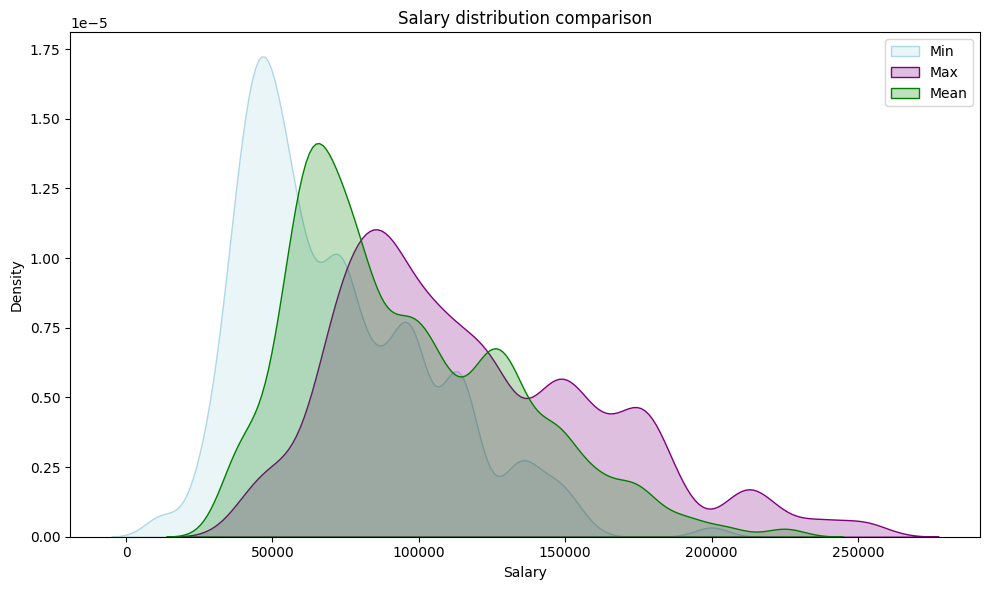

In [9]:
plt.figure(figsize=(10,6))
ax = plt.gca()
sns.kdeplot(
    data = df_ch0,
    x = 'sal_min',
    color = 'lightblue',
    label = 'Min',
    fill='lightblue'
)
sns.kdeplot(
    data = df_ch0,
    x = 'sal_max',
    color = 'purple',
    label = 'Max',
    fill = 'purple'
)
sns.kdeplot(
    data = df_ch0,
    x = 'sal_mean',
    color = 'green',
    label = 'Mean',
    fill = 'green'
)

plt.xlabel('Salary')
plt.title('Salary distribution comparison')
plt.legend()
plt.tight_layout()

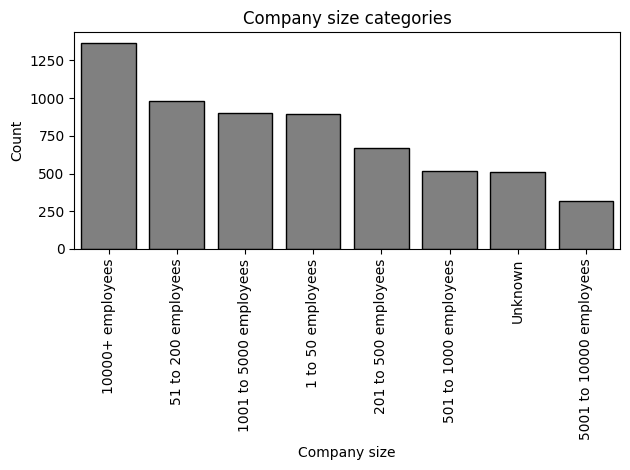

In [10]:
sns.countplot(
    data = df_ch0,
    x = 'Size',
    color='grey',
    edgecolor = 'black',
    order=df_ch0['Size'].value_counts().index
)
plt.xticks(rotation = 90)
plt.xlabel('Company size')
plt.ylabel('Count')
plt.title('Company size categories')
plt.tight_layout()

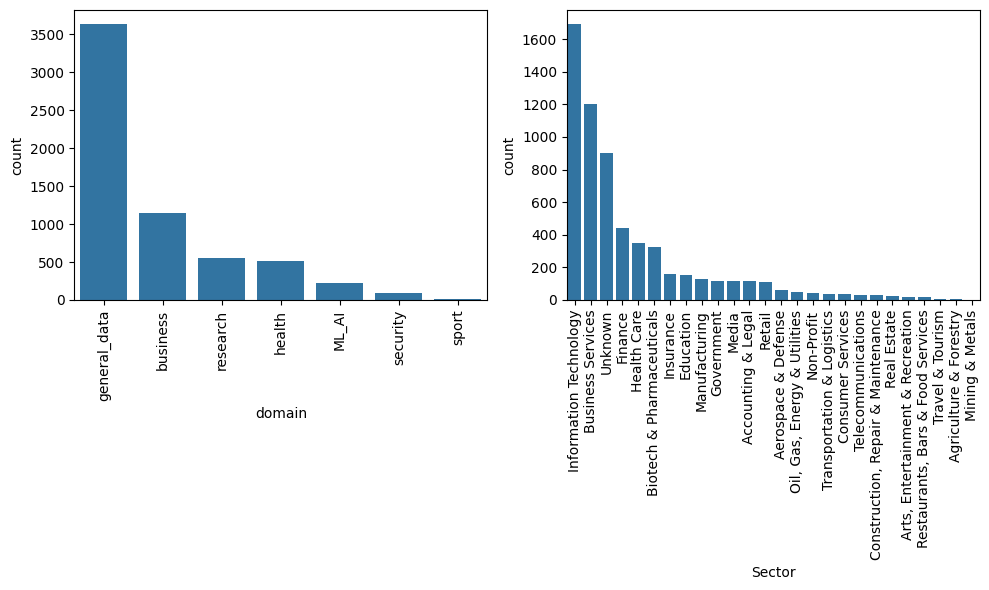

In [11]:
fig, axes = plt.subplots(1,2, figsize = (10,6))

ax1 = axes[0]
ax2 = axes[1]

sns.countplot(
    data = df_ch0,
    x = 'domain',
    ax = ax1,
    order = df_ch0['domain'].value_counts().index
)

sns.countplot(
    data = df_ch0,
    x = 'Sector',
    ax = ax2,
    order = df_ch0['Sector'].value_counts().index
)

plt.setp(ax1.get_xticklabels(), rotation=90)
plt.setp(ax2.get_xticklabels(), rotation=90)

plt.tight_layout()



## Feature engineering
We need to convert categories to numerical
Get dummies just in case we need them

In [12]:
cat_cols = ['Size', 'Sector', 'state', 'ownership_clean',
            'seniority_combined', 'job_title_family']
X_ohe = pd.get_dummies(df_ch0[cat_cols], drop_first=False, dtype=int)
df_ch0 = pd.concat([df_ch0, X_ohe], axis = 1)
df_ch0

,Job Description,Rating,Size,Founded,Industry,Sector,role_source,state,ownership_clean,job_description_clean,...,seniority_combined_manager,seniority_combined_mid,seniority_combined_principal,seniority_combined_senior,seniority_combined_supervisor,seniority_combined_unknown,job_title_family_data_analyst,job_title_family_data_engineer,job_title_family_data_scientist,job_title_family_scientist
0,"ABOUT HOPPER\n\nAt Hopper, we’re on a mission ...",3.5,501 to 1000 employees,2007,Travel Agencies,Travel & Tourism,data_scientist,NY,private,hopper mission make booking travel faster easi...,...,0,0,0,1,0,0,0,0,1,0
1,"At Noom, we use scientifically proven methods ...",4.5,1001 to 5000 employees,2008,"Health, Beauty, & Fitness",Consumer Services,data_scientist,NY,private,noom use scientifically proven methods help us...,...,0,0,0,0,0,1,0,0,1,0
2,Decode_M\n\nhttps://www.decode-m.com/\n\nData ...,NaN,1 to 50 employees,<NA>,Unknown,Unknown,data_scientist,NY,unknown,decode https www com data science manager job ...,...,1,0,0,0,0,0,0,0,1,0
3,Sapphire Digital seeks a dynamic and driven mi...,3.4,201 to 500 employees,2019,Internet,Information Technology,data_scientist,NJ,private,sapphire digital seeks dynamic driven mid leve...,...,0,1,0,0,0,0,1,0,0,0
4,"Director, Data Science - (200537)\nDescription...",3.4,51 to 200 employees,2007,Advertising & Marketing,Business Services,data_scientist,NY,private,director data science description edelman inte...,...,1,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6157,Maintains systems to protect data from unautho...,2.5,51 to 200 employees,<NA>,Staffing & Outsourcing,Business Services,data_analyst,CO,private,maintains systems protect data unauthorized us...,...,0,0,0,0,0,1,1,0,0,0
6158,Position:\nSenior Data Analyst (Corporate Audi...,2.9,10000+ employees,1935,Wholesale,Business Services,data_analyst,CO,public,position senior data analyst corporate audit j...,...,0,0,0,1,0,0,1,0,0,0
6159,"Title: Technical Business Analyst (SQL, Data a...",NaN,Unknown,<NA>,Unknown,Unknown,data_analyst,CO,unknown,title technical business analyst sql data anal...,...,0,0,0,0,0,1,1,0,0,0
6160,Summary\n\nResponsible for working cross-funct...,3.1,201 to 500 employees,1984,Enterprise Software & Network Solutions,Information Technology,data_analyst,CO,private,summary responsible working cross functionally...,...,0,0,0,0,0,1,1,0,0,0


In [13]:
df_ch0['title_rich'] = df_ch0['domain'] + '_' + df_ch0['job_title_family']

df_ch0[['title_rich', 'domain', 'job_title_family']]

,title_rich,domain,job_title_family
0,general_data_data_scientist,general_data,data_scientist
1,business_data_scientist,business,data_scientist
2,general_data_data_scientist,general_data,data_scientist
3,general_data_data_analyst,general_data,data_analyst
4,general_data_data_scientist,general_data,data_scientist
...,...,...,...
6157,general_data_data_analyst,general_data,data_analyst
6158,business_data_analyst,business,data_analyst
6159,business_data_analyst,business,data_analyst
6160,business_data_analyst,business,data_analyst


In [14]:
df_ch0['size_code']       = df_ch0['Size'].astype('category').cat.codes
df_ch0['sector_code']     = df_ch0['Sector'].astype('category').cat.codes
df_ch0['state_code']      = df_ch0['state'].astype('category').cat.codes
df_ch0['ownership_code']  = df_ch0['ownership_clean'].astype('category').cat.codes
df_ch0['seniority_code']  = df_ch0['seniority_combined'].astype('category').cat.codes
df_ch0['title_code']      = df_ch0['job_title_family'].astype('category').cat.codes
df_ch0['title_rich_code'] = df_ch0['title_rich'].astype('category').cat.codes

In [15]:
df_ch0 = df_ch0.dropna(subset=['sal_mean']) # Important to drop the NAs here so that the columns align

response = df_ch0['sal_mean']
features = df_ch0[[
            # Company
            'size_code', 'sector_code', 'state_code','ownership_code',
            # Role
            'seniority_code', 'title_code',
            # Skills
            'core_programming__basic', 'core_programming__intermediate', 
            'core_programming__advanced', 'data_engineering_pipelines__basic',
            'data_engineering_pipelines__intermediate',
            'data_engineering_pipelines__advanced', 'ml_ai__basic',
            'ml_ai__intermediate', 'ml_ai__advanced', 'analytics_stats__basic',
            'analytics_stats__intermediate', 'analytics_stats__advanced',
            'bi_viz__basic', 'bi_viz__intermediate', 'bi_viz__advanced',
            'cloud__basic', 'cloud__intermediate', 'cloud__advanced',
            'db_storage__basic', 'db_storage__intermediate', 'db_storage__advanced',
            'productivity_workflow__basic', 'productivity_workflow__intermediate',
            'productivity_workflow__advanced', 'soft_skills__core',
            'soft_skills__leadership', 'domain_specific__none'
            ]]

### Checks
* Shape align (same number of rows)
* Response has no NAs
* Response has no zeroes
* Features are all integers or numeric

In [16]:
features.shape[0] == response.shape[0]

True

In [17]:
sum(response.isna())

0

In [18]:
response.describe()

count      6161.000000
mean      94907.407888
std       37916.569933
min       33500.000000
25%       64500.000000
50%       85500.000000
75%      122000.000000
max      225000.000000
Name: sal_mean, dtype: float64

In [19]:
features.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6161 entries, 0 to 6161
Data columns (total 33 columns):
 #   Column                                    Non-Null Count  Dtype
---  ------                                    --------------  -----
 0   size_code                                 6161 non-null   int8 
 1   sector_code                               6161 non-null   int8 
 2   state_code                                6161 non-null   int8 
 3   ownership_code                            6161 non-null   int8 
 4   seniority_code                            6161 non-null   int8 
 5   title_code                                6161 non-null   int8 
 6   core_programming__basic                   6161 non-null   int64
 7   core_programming__intermediate            6161 non-null   int64
 8   core_programming__advanced                6161 non-null   int64
 9   data_engineering_pipelines__basic         6161 non-null   int64
 10  data_engineering_pipelines__intermediate  6161 non-null   int64
 

In [20]:
features.isna().apply(lambda x: (sum(x) / (len(features)))*100).sort_values()

size_code                                   0.0
soft_skills__core                           0.0
productivity_workflow__advanced             0.0
productivity_workflow__intermediate         0.0
productivity_workflow__basic                0.0
db_storage__advanced                        0.0
db_storage__intermediate                    0.0
db_storage__basic                           0.0
cloud__advanced                             0.0
cloud__intermediate                         0.0
cloud__basic                                0.0
bi_viz__advanced                            0.0
bi_viz__intermediate                        0.0
bi_viz__basic                               0.0
analytics_stats__advanced                   0.0
soft_skills__leadership                     0.0
analytics_stats__intermediate               0.0
ml_ai__advanced                             0.0
ml_ai__intermediate                         0.0
ml_ai__basic                                0.0
data_engineering_pipelines__advanced    

## Save data

In [22]:
from job_intel.config import PROCESSED_DATA_DIR
df_ch0.to_csv(PROCESSED_DATA_DIR / 'salary_model_dfv01.csv', index=False)

# === End of Notebook ===